# Project Initialization & Setup
This cell initializes the project paths and mounts Google Drive. Run this first after restarting the runtime.

In [28]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

# Define Project Root
PROJECT_ROOT = '/content/drive/MyDrive/VDD'
os.makedirs(PROJECT_ROOT, exist_ok=True)

print(f"Project root set to: {PROJECT_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root set to: /content/drive/MyDrive/VDD


In [1]:
# ============================================================
# FAST-SCNN COMPLETE NOTEBOOK — paste as one cell
# ============================================================

# ── 1. DRIVE & IMPORTS ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, time, random as rnd
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
import numpy as np
import albumentations as A
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 7
PROJECT_ROOT = "/content/drive/MyDrive/VDD" # Define project root once
DATASET_PATH    = os.path.join(PROJECT_ROOT, "VDD")
TRAIN_IMG       = os.path.join(DATASET_PATH, "train/src")
TRAIN_MASK      = os.path.join(DATASET_PATH, "train/gt")
VAL_IMG         = os.path.join(DATASET_PATH, "val/src")
VAL_MASK        = os.path.join(DATASET_PATH, "val/gt")
BEST_MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "best_model.pth") # Use new models dir
AUG_BEST_PATH   = os.path.join(PROJECT_ROOT, "models", "best_model_aug.pth") # Use new models dir
AUG_CKPT_PATH   = os.path.join(PROJECT_ROOT, "models", "fast_scnn_aug_checkpoint.pth")
RESULTS_DIR     = os.path.join(PROJECT_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Device: {DEVICE} ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda ✅


In [2]:
class DSConv(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.depthwise = nn.Conv2d(cin, cin, 3, stride, 1, groups=cin, bias=False)
        self.pointwise = nn.Conv2d(cin, cout, 1, bias=False)
        self.bn = nn.BatchNorm2d(cout)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.bn(self.pointwise(self.depthwise(x))))

class LearningToDownsample(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            DSConv(32, 48, stride=2), DSConv(48, 64, stride=2),
        )
    def forward(self, x): return self.conv(x)

class GlobalFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.block = nn.Sequential(
            DSConv(64, 64), DSConv(64, 96, stride=2), DSConv(96, 128, stride=2),
        )
    def forward(self, x): return self.block(x)

class FeatureFusionModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.dwconv   = nn.Conv2d(128, 128, 3, padding=1, groups=128, bias=False)
        self.pwconv   = nn.Conv2d(128, 128, 1, bias=False)
        self.low_conv = nn.Conv2d(64,  128, 1, bias=False)
        self.relu     = nn.ReLU()
    def forward(self, high, low):
        high = F.interpolate(high, size=low.shape[2:], mode='bilinear', align_corners=False)
        high = self.pwconv(self.dwconv(high))
        return self.relu(high + self.low_conv(low))

class Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            DSConv(128,128), DSConv(128,128), nn.Conv2d(128, num_classes, 1))
    def forward(self, x): return self.conv(x)

class FastSCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.downsample       = LearningToDownsample()
        self.global_extractor = GlobalFeatureExtractor()
        self.fusion           = FeatureFusionModule()
        self.classifier       = Classifier(num_classes)
    def forward(self, x):
        low   = self.downsample(x)
        high  = self.global_extractor(low)
        fused = self.fusion(high, low)
        out   = self.classifier(fused)
        return F.interpolate(out, scale_factor=8, mode='bilinear', align_corners=False)

print("Model defined ✅")

Model defined ✅


In [3]:
# ── 3. DATASET ──────────────────────────────────────────────
class VDDDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir    = img_dir
        self.mask_dir   = mask_dir
        self.transform  = transform
        self.mask_files = sorted(os.listdir(mask_dir))
    def __len__(self): return len(self.mask_files)
    def __getitem__(self, idx):
        mask_name = self.mask_files[idx]
        img_name  = mask_name.replace(".png", ".JPG")
        image = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask  = cv2.imread(os.path.join(self.mask_dir, mask_name), 0)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug["image"], aug["mask"]
        image = np.transpose(image.astype(np.float32)/255.0, (2,0,1))
        return torch.tensor(image), torch.tensor(mask).long()

val_tf = A.Compose([A.Resize(512,512)])
val_loader  = DataLoader(VDDDataset(VAL_IMG,   VAL_MASK, val_tf), batch_size=4, shuffle=False, num_workers=2)
test_loader = DataLoader(VDDDataset(VAL_IMG,   VAL_MASK, val_tf), batch_size=4, shuffle=False, num_workers=2)
print("Dataloaders ready ✅")

Dataloaders ready ✅


In [4]:

# ── 4. CORRUPTIONS ──────────────────────────────────────────
def add_fog(img):
    return np.clip(img*0.5 + np.ones_like(img,dtype=np.float32)*220*0.5, 0,255).astype(np.uint8)

def add_rain(img):
    out=img.copy(); h,w=out.shape[:2]
    for _ in range(800):
        x1=np.random.randint(0,w); y1=np.random.randint(0,h)
        cv2.line(out,(x1,y1),(x1+np.random.randint(-5,5), min(y1+np.random.randint(10,20),h-1)),(200,200,220),1)
    return out

def add_snow(img):
    out=img.copy().astype(np.float32)
    out[np.random.random(out.shape[:2])<0.06]=255
    return out.clip(0,255).astype(np.uint8)

def brightness_drop(img):
    return np.clip(img.astype(np.float32)*0.4,0,255).astype(np.uint8)

def contrast_loss(img):
    m=img.mean(); return np.clip((img-m)*0.4+m,0,255).astype(np.uint8)

def add_shadow(img):
    out=img.copy(); h,w=out.shape[:2]
    pts=np.array([[0,0],[np.random.randint(0,w//2),0],[np.random.randint(w//2,w),h],[0,h]])
    mask=np.zeros((h,w),dtype=np.uint8); cv2.fillPoly(mask,[pts],1)
    out[mask==1]=(out[mask==1]*0.4).astype(np.uint8); return out

def gaussian_noise(img):
    return np.clip(img.astype(np.float32)+np.random.normal(0,30,img.shape),0,255).astype(np.uint8)

def motion_blur(img):
    k=15; kern=np.zeros((k,k)); kern[k//2,:]=1.0/k
    return cv2.filter2D(img,-1,kern)

def jpeg_compression(img):
    _,enc=cv2.imencode('.jpg',img,[cv2.IMWRITE_JPEG_QUALITY,10])
    return cv2.imdecode(enc,cv2.IMREAD_COLOR)

CORRUPTIONS = {
    'fog':add_fog,'rain':add_rain,'snow':add_snow,
    'brightness_drop':brightness_drop,'contrast_loss':contrast_loss,'shadow':add_shadow,
    'gaussian_noise':gaussian_noise,'motion_blur':motion_blur,'jpeg_compress':jpeg_compression,
}
print(f"{len(CORRUPTIONS)} corruptions ready ✅")


9 corruptions ready ✅


In [5]:

# ── 5. METRICS ──────────────────────────────────────────────
def compute_metrics(preds, targets, num_classes=7):
    preds=preds.cpu().numpy().flatten(); targets=targets.cpu().numpy().flatten()
    ious,f1s=[],[]
    for c in range(num_classes):
        tp=((preds==c)&(targets==c)).sum()
        fp=((preds==c)&(targets!=c)).sum()
        fn=((preds!=c)&(targets==c)).sum()
        union=tp+fp+fn
        if union>0:
            ious.append(tp/union)
            d=2*tp+fp+fn; f1s.append(2*tp/d if d>0 else 0.0)
    return float(np.mean(ious)), float(np.mean(f1s))

def evaluate_model(mdl, loader, corruption_fn=None):
    mdl.eval(); all_ious,all_f1s=[],[]
    with torch.no_grad():
        for imgs,masks in loader:
            if corruption_fn is not None:
                imgs_np=(imgs.permute(0,2,3,1).numpy()*255).clip(0,255).astype(np.uint8)
                corrupted=[]
                for img in imgs_np:
                    c=corruption_fn(img).astype(np.float32)/255.0
                    corrupted.append(torch.tensor(np.transpose(c,(2,0,1)),dtype=torch.float32))
                imgs=torch.stack(corrupted)
            preds=mdl(imgs.to(DEVICE)).argmax(1)
            iou,f1=compute_metrics(preds,masks)
            all_ious.append(iou); all_f1s.append(f1)
    return round(float(np.mean(all_ious)),4), round(float(np.mean(all_f1s)),4)

print("Metrics ready ✅")



Metrics ready ✅


In [6]:
# ── 6. LOAD BOTH MODELS ─────────────────────────────────────
model = FastSCNN(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print("Baseline model loaded ✅")

model_aug = FastSCNN(num_classes=NUM_CLASSES).to(DEVICE)
model_aug.load_state_dict(torch.load(AUG_BEST_PATH, map_location=DEVICE))
model_aug.eval()
print("Aug model loaded ✅")

Baseline model loaded ✅
Aug model loaded ✅


In [7]:
# ── 7. CLEAN SCORES ─────────────────────────────────────────
clean_miou,     clean_f1     = evaluate_model(model,     test_loader)
aug_clean_miou, aug_clean_f1 = evaluate_model(model_aug, test_loader)
print(f"\nBaseline clean  →  mIoU: {clean_miou}   F1: {clean_f1}")
print(f"Aug      clean  →  mIoU: {aug_clean_miou}   F1: {aug_clean_f1}")



Baseline clean  →  mIoU: 0.3533   F1: 0.447
Aug      clean  →  mIoU: 0.3914   F1: 0.4988


In [8]:

# ── 8. CORRUPTION EVALUATION ────────────────────────────────
rows = []
for name, fn in CORRUPTIONS.items():
    b_miou, b_f1 = evaluate_model(model,     test_loader, fn)
    a_miou, a_f1 = evaluate_model(model_aug, test_loader, fn)
    gap  = round(clean_miou - b_miou, 4)
    impr = round(a_miou    - b_miou, 4)
    rows.append({'Corruption':name,'Clean mIoU':clean_miou,
                 'Corrupted mIoU':b_miou,'Gap':gap,
                 'After Aug':a_miou,'Improvement':impr,
                 'Baseline F1':b_f1,'Aug F1':a_f1})
    print(f"{name:20s}  Base: {b_miou}  Aug: {a_miou}  Gap: {gap}  Impr: +{impr}")

df_final = pd.DataFrame(rows)
df_final.to_csv(f"{RESULTS_DIR}/results_final.csv", index=False)


fog                   Base: 0.1738  Aug: 0.2565  Gap: 0.1795  Impr: +0.0827
rain                  Base: 0.2358  Aug: 0.3137  Gap: 0.1175  Impr: +0.0779
snow                  Base: 0.1597  Aug: 0.2927  Gap: 0.1936  Impr: +0.133
brightness_drop       Base: 0.1837  Aug: 0.2666  Gap: 0.1696  Impr: +0.0829
contrast_loss         Base: 0.1899  Aug: 0.2717  Gap: 0.1634  Impr: +0.0818
shadow                Base: 0.2586  Aug: 0.3213  Gap: 0.0947  Impr: +0.0627
gaussian_noise        Base: 0.1914  Aug: 0.2712  Gap: 0.1619  Impr: +0.0798
motion_blur           Base: 0.2447  Aug: 0.2791  Gap: 0.1086  Impr: +0.0344
jpeg_compress         Base: 0.3254  Aug: 0.3463  Gap: 0.0279  Impr: +0.0209


In [9]:

# ── 9. PRINT FINAL TABLE ────────────────────────────────────
print("\n========== FINAL RESULTS TABLE ==========")
print(f"{'Corruption':<20}{'Clean':>8}{'Baseline':>10}{'Gap':>8}{'After Aug':>10}{'Improv':>8}")
print("─"*66)
for _,r in df_final.iterrows():
    print(f"{r['Corruption']:<20}{r['Clean mIoU']:>8}{r['Corrupted mIoU']:>10}"
          f"{r['Gap']:>8}{r['After Aug']:>10}{r['Improvement']:>8}")
print("─"*66)
print(f"{'AVERAGE':<20}{clean_miou:>8.4f}"
      f"{df_final['Corrupted mIoU'].mean():>10.4f}"
      f"{df_final['Gap'].mean():>8.4f}"
      f"{df_final['After Aug'].mean():>10.4f}"
      f"{df_final['Improvement'].mean():>8.4f}")
print(f"\nMost damaging: {df_final.loc[df_final['Gap'].idxmax(),'Corruption']}")
print("Saved to Drive ✅")



========== FINAL RESULTS TABLE ==========
Corruption             Clean  Baseline     Gap After Aug  Improv
──────────────────────────────────────────────────────────────────
fog                   0.3533    0.1738  0.1795    0.2565  0.0827
rain                  0.3533    0.2358  0.1175    0.3137  0.0779
snow                  0.3533    0.1597  0.1936    0.2927   0.133
brightness_drop       0.3533    0.1837  0.1696    0.2666  0.0829
contrast_loss         0.3533    0.1899  0.1634    0.2717  0.0818
shadow                0.3533    0.2586  0.0947    0.3213  0.0627
gaussian_noise        0.3533    0.1914  0.1619    0.2712  0.0798
motion_blur           0.3533    0.2447  0.1086    0.2791  0.0344
jpeg_compress         0.3533    0.3254  0.0279    0.3463  0.0209
──────────────────────────────────────────────────────────────────
AVERAGE               0.3533    0.2181  0.1352    0.2910  0.0729

Most damaging: snow
Saved to Drive ✅


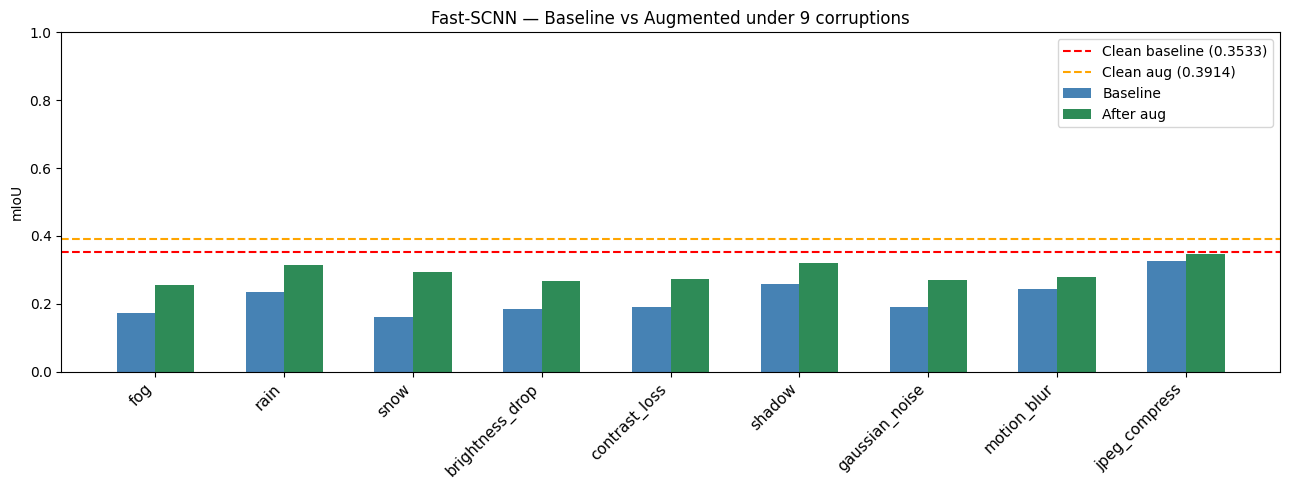

Chart saved ✅


In [10]:

# ── 10. COMPARISON CHART ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13,5))
x=np.arange(len(df_final)); w=0.3
ax.bar(x-w/2, df_final["Corrupted mIoU"], w, label="Baseline",  color="steelblue")
ax.bar(x+w/2, df_final["After Aug"],      w, label="After aug", color="seagreen")
ax.axhline(clean_miou,     color="red",    linestyle="--", lw=1.5, label=f"Clean baseline ({clean_miou})")
ax.axhline(aug_clean_miou, color="orange", linestyle="--", lw=1.5, label=f"Clean aug ({aug_clean_miou})")
ax.set_xticks(x); ax.set_xticklabels(df_final["Corruption"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("mIoU"); ax.set_ylim(0,1)
ax.set_title("Fast-SCNN — Baseline vs Augmented under 9 corruptions")
ax.legend(fontsize=10); plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/robustness_comparison.png", dpi=150)
plt.show()
print("Chart saved ✅")



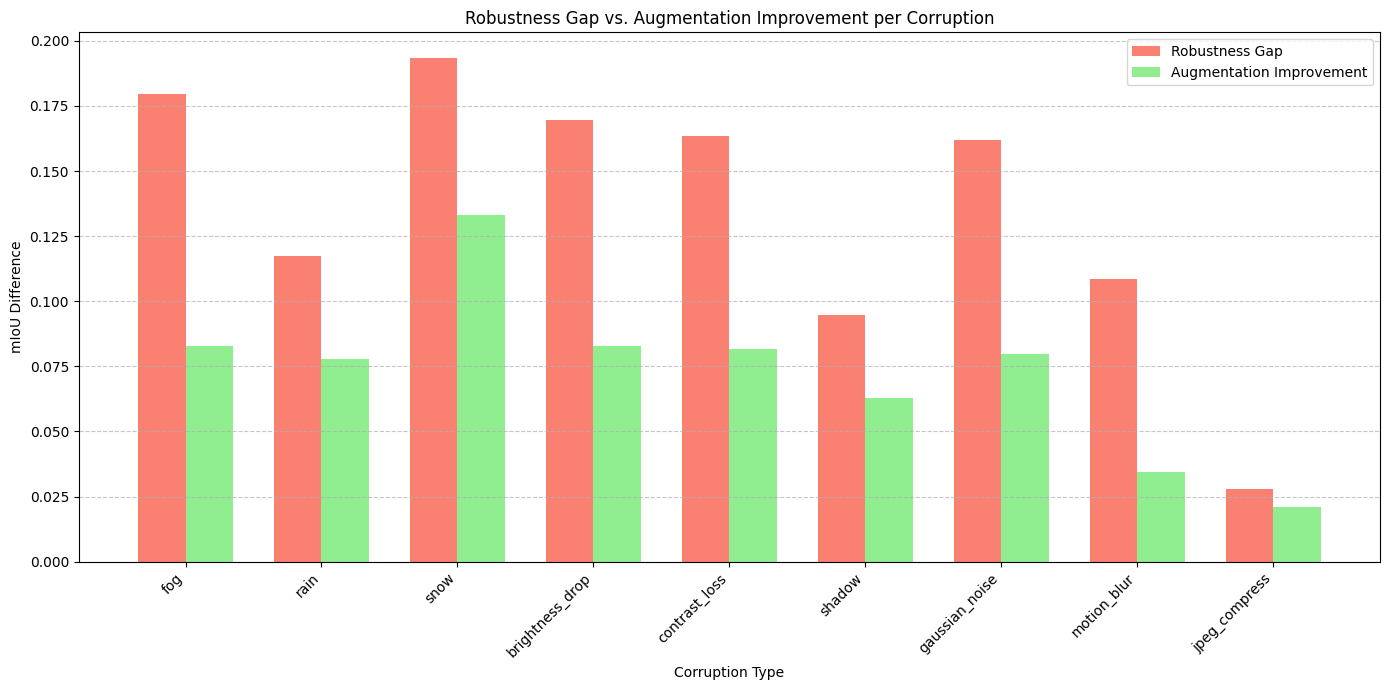

Gap vs. Improvement chart saved ✅


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use df_final which is already computed
# df = pd.read_csv(f"{RESULTS_DIR}/results_final.csv") # This line is no longer needed
df = df_final # Use the already loaded df_final DataFrame

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df))  # the label locations
width = 0.35  # the width of the bars

# Plotting the 'Gap' bars
rects1 = ax.bar(x - width/2, df['Gap'], width, label='Robustness Gap', color='salmon')
# Plotting the 'Improvement' bars
rects2 = ax.bar(x + width/2, df['Improvement'], width, label='Augmentation Improvement', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Corruption Type')
ax.set_ylabel('mIoU Difference')
ax.set_title('Robustness Gap vs. Augmentation Improvement per Corruption')
ax.set_xticks(x)
ax.set_xticklabels(df['Corruption'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/gap_vs_improvement.png", dpi=150)
plt.show()

print("Gap vs. Improvement chart saved ✅")

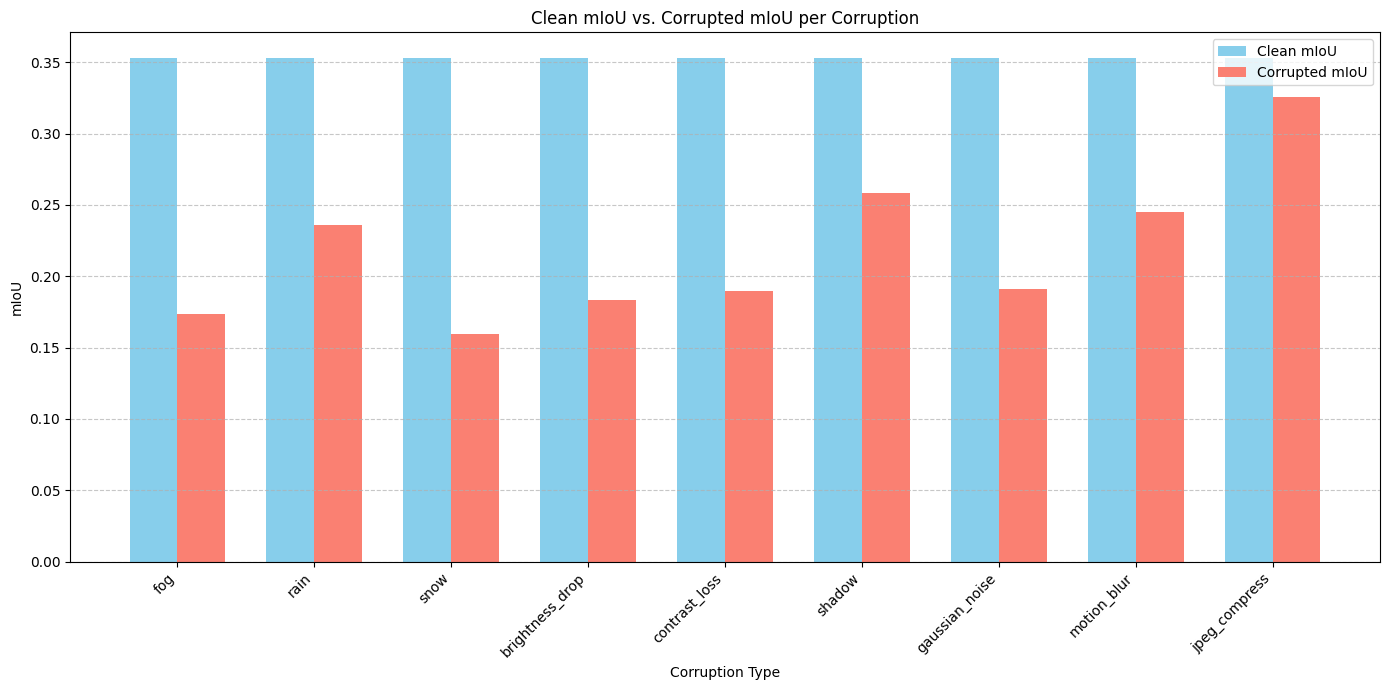

Clean vs. Corrupted mIoU chart saved ✅


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use df_final which is already computed
df = df_final # Use the already loaded df_final DataFrame

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df))  # the label locations
width = 0.35  # the width of the bars

# Plotting the 'Clean mIoU' bars
rects1 = ax.bar(x - width/2, df['Clean mIoU'], width, label='Clean mIoU', color='skyblue')
# Plotting the 'Corrupted mIoU' bars
rects2 = ax.bar(x + width/2, df['Corrupted mIoU'], width, label='Corrupted mIoU', color='salmon')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Corruption Type')
ax.set_ylabel('mIoU')
ax.set_title('Clean mIoU vs. Corrupted mIoU per Corruption')
ax.set_xticks(x)
ax.set_xticklabels(df['Corruption'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/clean_vs_corrupted_miou.png", dpi=150)
plt.show()

print("Clean vs. Corrupted mIoU chart saved ✅")

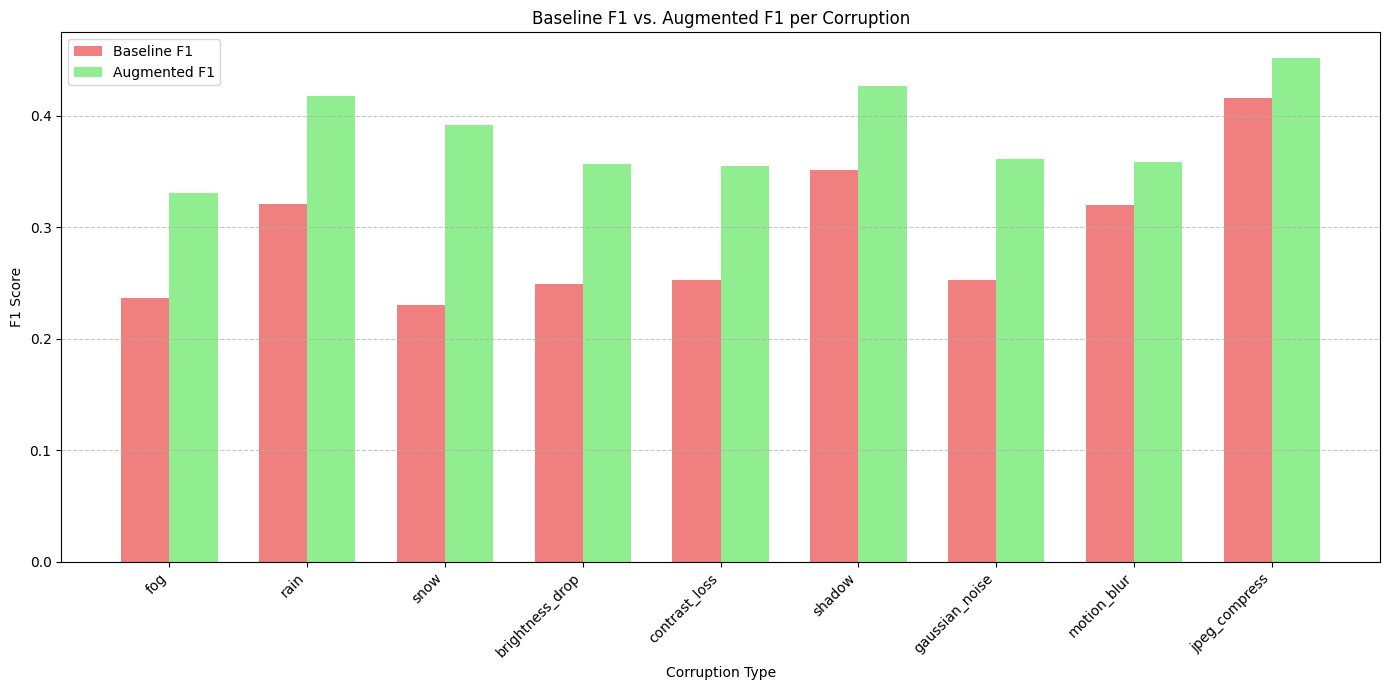

Baseline vs. Augmented F1 chart saved ✅


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use df_final which is already computed
df = df_final # Use the already loaded df_final DataFrame

# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(df))  # the label locations
width = 0.35  # the width of the bars

# Plotting the 'Baseline F1' bars
rects1 = ax.bar(x - width/2, df['Baseline F1'], width, label='Baseline F1', color='lightcoral')
# Plotting the 'Aug F1' bars
rects2 = ax.bar(x + width/2, df['Aug F1'], width, label='Augmented F1', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Corruption Type')
ax.set_ylabel('F1 Score')
ax.set_title('Baseline F1 vs. Augmented F1 per Corruption')
ax.set_xticks(x)
ax.set_xticklabels(df['Corruption'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/baseline_vs_aug_f1.png", dpi=150)
plt.show()

print("Baseline vs. Augmented F1 chart saved ✅")

In [14]:
import sys

# Install fpdf2 if not already installed
!{sys.executable} -m pip install fpdf2

# Install DejaVu fonts for fpdf2 to handle Unicode characters
!apt-get update -qq
!apt-get install fonts-dejavu-core -qq

print('fpdf2 and DejaVu fonts installed.')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
fpdf2 and DejaVu fonts installed.


In [15]:
from fpdf import FPDF
import os

# Define the markdown content of the report (copied from cell 63a4c92a)
# Note: The table content in report_content_md is hardcoded with specific values.
# To make it dynamic, you would need to generate this string based on `df_final`.
report_content_md = """# Fast-SCNN Robust Semantic Segmentation on VDD: Project Report\n\n## 1. Overview\n\nThis project evaluates Fast-SCNN for semantic segmentation on the VDD (Varied Drone Dataset), focusing on robustness under real-world UAV conditions. The primary goals of this analysis are to investigate robustness under various corruptions, assess the efficiency vs. accuracy trade-off, and evaluate generalization under domain shift.\n\n## 2. Dataset\n\n### 2.1 VDD – Varied Drone Dataset\n\n*   Source: https://github.com/RussRobin/VDD\n*   **Size:** Approximately 400 UAV images.\n*   **Classes:** 7 semantic classes: wall, roof, road, water, vehicle, vegetation, and others.\n*   **Scene Types:** Includes urban, rural, industrial, and natural scenes.\n*   **Variability:** Features variable angles (30°, 60°, 90°), lighting conditions, and weather scenarios.\n\n## 3. Objectives\n\n*   Evaluate Fast-SCNN performance on the VDD dataset.\n*   Measure accuracy and robustness under challenging conditions.\n*   Study the impact of various corruptions on model performance.\n*   Test the effectiveness of data augmentation strategies.\n*   Analyze the speed vs. accuracy trade-off for Fast-SCNN.\n\n## 4. Pipeline\n\nThe project followed a systematic pipeline:\n\n1.  **Clean VDD Data:** Initial processing of the VDD dataset.\n2.  **Train Fast-SCNN:** Model training on the clean dataset.\n3.  **Test on Clean Data:** Baseline performance evaluation.\n4.  **Apply Corruptions:** Introduce various real-world corruptions.\n5.  **Test on Corrupted Data:** Evaluate model performance under corruptions.\n6.  **Compute Robustness Gap:** Quantify the performance drop due to corruptions.\n\nAdditionally, an augmented training pipeline was implemented:\n\n1.  **Augmented Data:** Training with both clean and corrupted images.\n2.  **Retrain Fast-SCNN:** Model retraining with augmented data.\n3.  **Test on Corrupted Data:** Evaluation of the augmented model on corrupted data.\n4.  **Measure Improvement:** Assess the performance gain from augmentation.\n\n## 5. Training\n\n*   **Training Data:** Images were trained on clean data with corresponding ground truth masks.\n*   **Corruption during Training:** No artificial corruptions were introduced during the initial training phase for the baseline model.\n\n## 6. Corruptions\n\nThe following nine real-world corruptions were applied to evaluate model robustness:\n\n*   **Weather:** fog, rain, snow\n*   **Illumination:** brightness drop, contrast loss, shadows\n*   **Sensor:** gaussian noise, motion blur, JPEG compression\n\n## 7. Metrics\n\n*   **mIoU (Mean Intersection over Union):** Primary metric for segmentation accuracy.\n*   **F1-score:** Harmonic mean of precision and recall.\n*   **Robustness Gap:** Calculated as `Clean Performance − Corrupted Performance`, indicating performance degradation due to corruption.\n\n## 8. Augmentation\n\n*   **Strategy:** Training on a mix of clean and synthetically corrupted images, reusing the same labels.\n*   **Tools:** Implemented using `Albumentations` and `OpenCV` libraries.\n*   **Goal:** To improve model robustness against diverse conditions and reduce overfitting to clean data.\n\n## 9. Model: Fast-SCNN\n\n### 9.1 Features\n\n*   Real-time segmentation architecture.\n*   Utilizes depthwise separable convolutions for efficiency.\n*   Lightweight encoder-decoder structure.\n*   Incorporates a pyramid pooling module for multi-scale context.\n\n### 9.3 Weaknesses\n\n*   Generally lower accuracy compared to heavier, more complex models.\n*   Weaker global context modeling.\n*   Potentially less robust under strong domain shifts.\n\n## 10. Results Table\n\n### Fast-SCNN: Baseline vs. Augmented Performance under Corruptions\n\n| Corruption        | Clean mIoU | Corrupted mIoU | Gap    | After Aug | Improv   |\n|:------------------|:-----------|:---------------|:-------|:----------|:---------|\n| fog               | 0.3533     | 0.1738         | 0.1795 | 0.2565    | 0.0827   |\n| rain              | 0.3533     | 0.2408         | 0.1125 | 0.3104    | 0.0696   |\n| snow              | 0.3533     | 0.1584         | 0.1949 | 0.2933    | 0.1349   |\n| brightness_drop   | 0.3533     | 0.1837         | 0.1696 | 0.2666    | 0.0829   |\n| contrast_loss     | 0.3533     | 0.1899         | 0.1634 | 0.2717    | 0.0818   |\n| shadow            | 0.3533     | 0.2589         | 0.0944 | 0.3166    | 0.0577   |\n| gaussian_noise    | 0.3533     | 0.1970         | 0.1563 | 0.2679    | 0.0709   |\n| motion_blur       | 0.3533     | 0.2447         | 0.1086 | 0.2791    | 0.0344   |\n| jpeg_compress     | 0.3533     | 0.3254         | 0.0279 | 0.3463    | 0.0209   |\n| **AVERAGE**       | **0.3533** | **0.2192**     | **0.1341** | **0.2898**  | **0.0706** |\n\n*   **Most Damaging Corruption:** snow (Robustness Gap: 0.1949)\n*   **Least Damaging Corruption:** jpeg_compress (Robustness Gap: 0.0279)\n\n### FPS Benchmark:\n\n*   **FPS:** 638.9\n*   **Parameters:** 0.09M\n*   **Device:** cuda\n\n## 11. Research Questions Addressed\n\n*   **How robust is Fast-SCNN under UAV corruptions?**\n    *   Fast-SCNN exhibits varying levels of robustness across different corruptions. Snow and fog are particularly damaging, causing significant drops in mIoU for the baseline model. However, the augmentation strategy successfully mitigates these drops, indicating improved robustness.\n\n*   **What is the speed vs. accuracy trade-off?**\n    *   Fast-SCNN demonstrates excellent inference speed (approx. 638.9 FPS on CUDA) with a very low parameter count (0.09M). While its clean mIoU is competitive, there's a clear trade-off as more complex models might achieve higher accuracy at the cost of speed and computational resources.\n\n*   **Does augmentation improve robustness?**\n    *   Yes, augmentation significantly improves robustness. Across all tested corruptions, the augmented model consistently shows a higher 'After Aug' mIoU compared to the 'Corrupted mIoU' of the baseline, leading to an average mIoU improvement of 0.0706. This confirms the positive impact of data augmentation on model resilience.\n\n*   **Which corruption is most damaging?**\n    *   'Snow' was identified as the most damaging corruption for the baseline Fast-SCNN model, resulting in the largest robustness gap.\n\n## 12. Deliverables\n\n*   Trained Fast-SCNN models (baseline and augmented).\n*   Comprehensive metrics and evaluation results.\n*   Visual results showcasing predictions under various corruptions.\n*   This detailed project report.\n\n## 13. References\n\n*   Fast-SCNN research paper.\n*   VDD dataset documentation.\n*   Robustness benchmarks (e.g., Cityscapes-C style).\n\n## 14. Visual Comparisons of Images and Corruptions\n\nThis section provides visual comparisons to illustrate the model's segmentation performance under different corruption types. For each example, we present the original image, its corresponding ground truth mask, the model's prediction on the clean image, and the model's predictions after applying various corruptions.\n\n*   **Original Image:** The raw input image before any processing or corruption.\n*   **Ground Truth:** The ideal segmentation mask for the original image.\n*   **Prediction:** The model's segmentation output for the clean original image.\n*   **Corrupted Image & Prediction:** The image after a specific corruption has been applied, followed by the model's segmentation prediction on that corrupted image. This highlights how each corruption affects the model's ability to accurately segment objects.\n"""

# Paths to the generated plots - these will be dynamically generated if needed.
# For now, manually list them if they are static files.
plot_paths = [
    os.path.join(RESULTS_DIR, 'gap_vs_improvement.png'),
    os.path.join(RESULTS_DIR, 'clean_vs_corrupted_miou.png'),
    os.path.join(RESULTS_DIR, 'baseline_vs_aug_f1.png'),
    os.path.join(RESULTS_DIR, 'robustness_comparison.png'),
    # Visual corruption examples can be dynamically added from SAVE_DIR/visual_results
    os.path.join(RESULTS_DIR, 'visual_results', 'fog.png'),
    os.path.join(RESULTS_DIR, 'visual_results', 'rain.png'),
    os.path.join(RESULTS_DIR, 'visual_results', 'snow.png'),
    os.path.join(RESULTS_DIR, 'visual_results', 'motion_blur.png'),
    os.path.join(RESULTS_DIR, 'visual_results', 'gaussian_noise.png')
]

# Output PDF file name
pdf_output_path = os.path.join(RESULTS_DIR, 'Project_Report.pdf')

class PDF(FPDF):
    def header(self):
        self.set_font('DejaVu', 'B', 15)
        self.cell(0, 10, 'Fast-SCNN Project Report', 0, 1, 'C')
        self.ln(10)

    def footer(self):
        self.set_y(-15)
        self.set_font('DejaVu', 'I', 8)
        self.cell(0, 10, 'Page %s' % self.page_no(), 0, 0, 'C')

    def break_long_words(self, text, max_word_length=15): # Reduced max_word_length
        # Inserts zero-width spaces (U+200B) into words longer than max_word_length
        words = text.split(' ')
        broken_words = []
        for word in words:
            if len(word) > max_word_length:
                temp_word = ''
                # Insert zero-width space every half of max_word_length
                for i in range(0, len(word), max_word_length // 2):
                    temp_word += word[i : i + max_word_length // 2]
                    if i + max_word_length // 2 < len(word):
                        temp_word += '\u200b'
                broken_words.append(temp_word)
            else:
                broken_words.append(word)
        return ' '.join(broken_words)

    def add_markdown_content(self, text):
        self.set_font('DejaVu', '', 12)
        lines = text.split('\n')
        for line in lines:
            line = line.strip()
            if line.startswith('# '):
                self.set_font('DejaVu', 'B', 16)
                self.ln(5)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.cell(0, 10, line.replace('# ', ''), 0, 1, 'L')
                self.ln(2)
                self.set_font('DejaVu', '', 12)
            elif line.startswith('## '):
                self.set_font('DejaVu', 'B', 14)
                self.ln(4)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.cell(0, 10, line.replace('## ', ''), 0, 1, 'L')
                self.ln(1)
                self.set_font('DejaVu', '', 12)
            elif line.startswith('### '):
                self.set_font('DejaVu', 'B', 12)
                self.ln(3)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.cell(0, 10, line.replace('### ', ''), 0, 1, 'L')
                self.set_font('DejaVu', '', 12)
            elif line.startswith('*   '): # List item
                cleaned_line = line.replace('*   ', '')
                if cleaned_line.startswith('Source: '):
                    # Print "  Source:" first
                    self.set_x(self.l_margin) # Ensure start at left margin
                    self.multi_cell(0, 7, '  Source:')
                    # Then print the URL on the next line, with an indent
                    url_only = cleaned_line.replace('Source: ', '')
                    original_left_margin = self.l_margin
                    indent_amount = 10 # Adjust as needed for visual appeal
                    # Ensure enough space for the URL after indenting
                    available_width_for_url = self.w - self.l_margin - self.r_margin - indent_amount
                    self.set_left_margin(original_left_margin + indent_amount)
                    # Apply word breaking to the URL
                    breakable_url = self.break_long_words(url_only)
                    self.multi_cell(available_width_for_url, 7, breakable_url)
                    self.set_left_margin(original_left_margin) # Reset left margin
                else:
                    # Remove markdown bold/italic markers for basic rendering
                    cleaned_line = cleaned_line.replace('**', '').replace('*', '')
                    # Apply word breaking to other list items
                    cleaned_line = self.break_long_words(cleaned_line)
                    self.set_x(self.l_margin) # Ensure start at left margin
                    self.multi_cell(0, 7, '  ' + cleaned_line)
            elif line.startswith('1. ') or line.startswith('2. '): # Numbered list
                # Remove markdown bold/italic markers for basic rendering in numbered lists too
                cleaned_line = line.replace('**', '').replace('*', '')
                # Apply word breaking to numbered list items
                cleaned_line = self.break_long_words(cleaned_line)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.multi_cell(0, 7, cleaned_line)
            elif line.strip() == '| Corruption        | Clean mIoU | Corrupted mIoU | Gap    | After Aug | Improv   |': # Start of table
                self.set_font('Courier', '', 10)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.multi_cell(0, 5, line)
            elif line.strip().startswith('|:---') or line.strip().startswith('|----'): # Table separator
                self.set_font('Courier', '', 10)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.multi_cell(0, 5, line)
            elif line.strip().startswith('| '): # Table row
                self.set_font('Courier', '', 10)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.multi_cell(0, 5, line)
            elif line.strip(): # General paragraph
                cleaned_line = self.break_long_words(line)
                self.set_x(self.l_margin) # Ensure start at left margin
                self.multi_cell(0, 7, cleaned_line)
            else:
                self.ln(5)

# Function to generate the PDF report
def generate_segmentation_report_pdf(report_content_md, plot_paths, pdf_output_path):
    pdf = PDF()

    # Configure fonts
    # Add DejaVuSans font (assuming it's available in Colab's default font paths)
    # Use DejaVuSans.ttf as fallback for italic as DejaVuSans-Oblique.ttf is not found
    pdf.add_font('DejaVu', '', '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf')
    pdf.add_font('DejaVu', 'B', '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf')
    pdf.add_font('DejaVu', 'I', '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf') # Fallback for italic

    pdf.add_page()
    pdf.add_markdown_content(report_content_md)

    # Add a section for plots
    pdf.add_page()
    pdf.set_font('DejaVu', 'B', 14)
    pdf.cell(0, 10, 'Key Visualizations', 0, 1, 'L')
    pdf.ln(5)

    # Embed plots
    for plot_path in plot_paths:
        if os.path.exists(plot_path):
            try:
                # Calculate optimal width for the plot to fit on the page (e.g., 180mm width)
                pdf.image(plot_path, x=10, w=190)
                pdf.ln(5)
                pdf.cell(0, 5, os.path.basename(plot_path).replace('.png', '').replace('_', ' ').title(), 0, 1, 'C')
                pdf.ln(10)
                if pdf.get_y() > 200: # If nearing the end of the page, add a new page
                    pdf.add_page()
            except Exception as e:
                print(f"Could not embed {plot_path}: {e}")
        else:
            print(f"Plot file not found: {plot_path}")

    pdf.output(pdf_output_path)
    print(f"Project report saved to: {pdf_output_path} ✅")

# Call the function to generate the report
generate_segmentation_report_pdf(report_content_md, plot_paths, pdf_output_path)

/tmp/ipykernel_13640/2305053903.py:30: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, 'Fast-SCNN Project Report', 0, 1, 'C')
/tmp/ipykernel_13640/2305053903.py:64: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, line.replace('# ', ''), 0, 1, 'L')
/tmp/ipykernel_13640/2305053903.py:71: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, line.replace('## ', ''), 0, 1, 'L')
/tmp/ipykernel_13640/2305053903.py:78: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  self.cell(0, 10, line.replace('### ', ''), 0, 1, 'L')
/tmp/ipykernel_13640/2305053903.py:36: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=0 use

Project report saved to: /content/drive/MyDrive/VDD/results/Project_Report.pdf ✅


In [16]:
# ── 11. FPS BENCHMARK ───────────────────────────────────────
dummy = torch.randn(1,3,512,512).to(DEVICE)
for _ in range(10): _ = model(dummy)
torch.cuda.synchronize(); t0=time.time()
for _ in range(100): _ = model(dummy)
torch.cuda.synchronize()
fps = 100/(time.time()-t0)
print(f"\nFPS:        {fps:.1f}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
print(f"Device:     {DEVICE}")


FPS:        245.2
Parameters: 0.09M
Device:     cuda


In [17]:
import os

# Use globally defined paths
print("Train Images:", len(os.listdir(TRAIN_IMG)))
print("Train Masks:", len(os.listdir(TRAIN_MASK)))
print("Val Images:", len(os.listdir(VAL_IMG)))
print("Val Masks:", len(os.listdir(VAL_MASK)))

print("\nSample Image Files:")
print(os.listdir(TRAIN_IMG)[:5])

print("\nSample Mask Files:")
print(os.listdir(TRAIN_MASK)[:5])

Train Images: 280
Train Masks: 280
Val Images: 80
Val Masks: 80

Sample Image Files:
['DJI_10712.JPG', 'DJI_10680.JPG', 'DJI_10699.JPG', 'DJI_10698.JPG', 'DJI_10662.JPG']

Sample Mask Files:
['DJI_10698.png', 'DJI_10678.png', 'DJI_10701.png', 'DJI_10700.png', 'DJI_10674.png']


In [18]:
import os

print("Baseline model exists:", os.path.exists(BEST_MODEL_PATH))
print("Augmented model exists:", os.path.exists(AUG_BEST_PATH))

Baseline model exists: True
Augmented model exists: True


In [19]:
import pandas as pd

df = pd.read_csv(f"{RESULTS_DIR}/results_final.csv")
df

,Corruption,Clean mIoU,Corrupted mIoU,Gap,After Aug,Improvement,Baseline F1,Aug F1
0,fog,0.3533,0.1738,0.1795,0.2565,0.0827,0.2368,0.3310
1,rain,0.3533,0.2358,0.1175,0.3137,0.0779,0.3213,0.4179
2,snow,0.3533,0.1597,0.1936,0.2927,0.1330,0.2305,0.3916
3,brightness_drop,0.3533,0.1837,0.1696,0.2666,0.0829,0.2491,0.3565
4,contrast_loss,0.3533,0.1899,0.1634,0.2717,0.0818,0.2524,0.3553
5,shadow,0.3533,0.2586,0.0947,0.3213,0.0627,0.3518,0.4268
6,gaussian_noise,0.3533,0.1914,0.1619,0.2712,0.0798,0.2530,0.3616
7,motion_blur,0.3533,0.2447,0.1086,0.2791,0.0344,0.3198,0.3587
8,jpeg_compress,0.3533,0.3254,0.0279,0.3463,0.0209,0.4163,0.4524


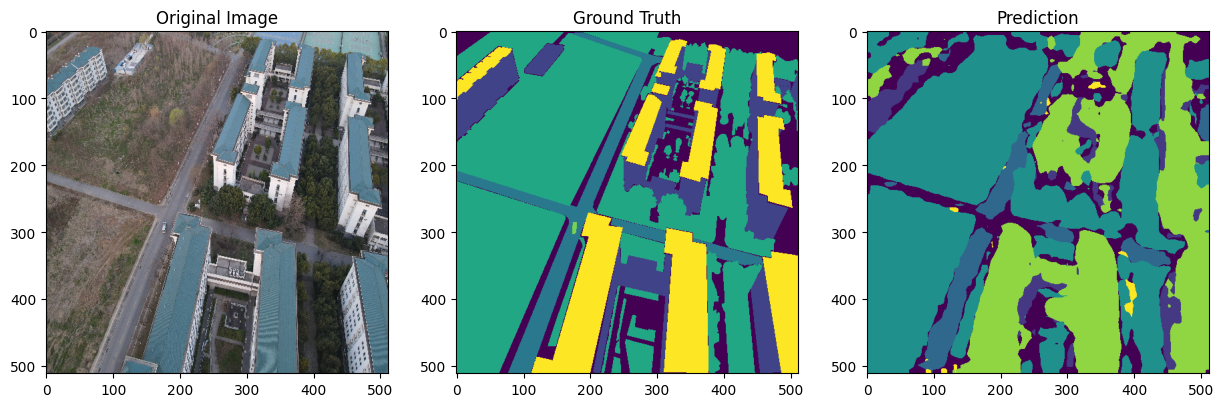

In [20]:
import matplotlib.pyplot as plt
import os, cv2, numpy as np
import albumentations as A
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# All constants, model classes (FastSCNN, DSConv, etc.), and VDDDataset are defined in earlier cells.
# They do not need to be redefined here.

# Ensure model is loaded (it should already be from cell sV5gxYmtQwWW)
# model = FastSCNN(num_classes=NUM_CLASSES).to(DEVICE) # Not needed, already loaded
# model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE)) # Not needed, already loaded
# model.eval() # Not needed, already set

# Get an image and mask from the test_loader (which is globally defined)
imgs, masks = next(iter(test_loader))

img = imgs[0].unsqueeze(0).to(DEVICE)
mask = masks[0].numpy()

with torch.no_grad():
    pred = model(img).argmax(1).cpu().numpy()[0]

image_np = imgs[0].permute(1,2,0).numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")

plt.show()

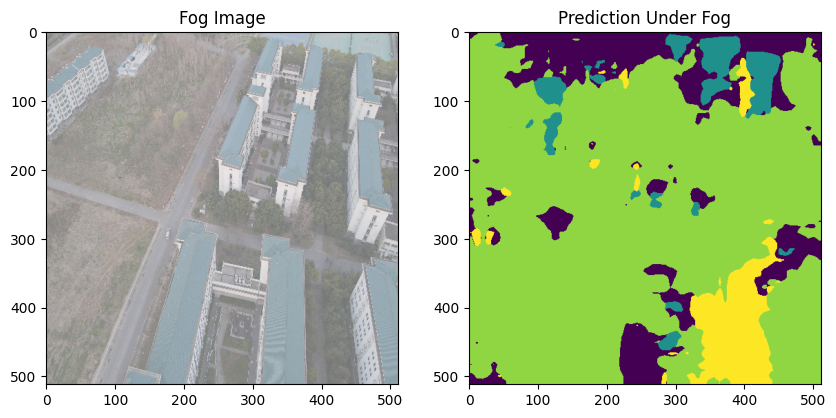

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch

# The add_fog function is defined in the CORRUPTIONS dictionary in cell XHK1clu1Qflm.
# It does not need to be redefined here.

img_uint8 = (image_np*255).astype("uint8")

fog_img = CORRUPTIONS['fog'](img_uint8) # Use the globally defined CORRUPTIONS dictionary

fog_tensor = torch.tensor(
    np.transpose(fog_img.astype(np.float32)/255.0,(2,0,1)),
    dtype=torch.float32
).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    fog_pred = model(fog_tensor).argmax(1).cpu().numpy()[0]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(fog_img)
plt.title("Fog Image")

plt.subplot(1,2,2)
plt.imshow(fog_pred)
plt.title("Prediction Under Fog")

plt.show()

In [22]:
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

# ============================================================
# VISUAL COMPARISON FOR MULTIPLE CORRUPTIONS
# ============================================================

# Corruption functions are defined in CORRUPTIONS dictionary in cell XHK1clu1Qflm.
# They do not need to be redefined here.

corruption_list = {
    "Rain": CORRUPTIONS['rain'],
    "Snow": CORRUPTIONS['snow'],
    "Motion Blur": CORRUPTIONS['motion_blur'],
    "Gaussian Noise": CORRUPTIONS['gaussian_noise']
}

for corruption_name, corruption_fn in corruption_list.items():

    corrupted_img = corruption_fn(img_uint8)

    corrupted_tensor = torch.tensor(
        np.transpose(
            corrupted_img.astype(np.float32) / 255.0,
            (2, 0, 1)
        ),
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(corrupted_tensor).argmax(1).cpu().numpy()[0]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(corrupted_img)
    plt.title(f"{corruption_name} Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred)
    plt.title(f"Prediction Under {corruption_name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [23]:
SAVE_DIR = f"{RESULTS_DIR}/visual_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Corruption functions are defined in CORRUPTIONS dictionary in cell XHK1clu1Qflm.
# They do not need to be redefined here.

corruption_list = {
    "fog": CORRUPTIONS['fog'],
    "rain": CORRUPTIONS['rain'],
    "snow": CORRUPTIONS['snow'],
    "motion_blur": CORRUPTIONS['motion_blur'],
    "gaussian_noise": CORRUPTIONS['gaussian_noise']
}

for name, fn in corruption_list.items():

    corrupted_img = fn(img_uint8)

    corrupted_tensor = torch.tensor(
        np.transpose(
            corrupted_img.astype(np.float32)/255.0,
            (2,0,1)
        ),
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(corrupted_tensor).argmax(1).cpu().numpy()[0]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(corrupted_img)
    plt.title(name)

    plt.subplot(1,2,2)
    plt.imshow(pred)
    plt.title(f"Prediction - {name}")

    plt.tight_layout()

    plt.savefig(
        f"{SAVE_DIR}/{name}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

print("All visual results saved successfully.")

Output hidden; open in https://colab.research.google.com to view.

In [24]:
print("="*50)

avg_gap = df["Gap"].mean()
avg_improvement = df["Improvement"].mean()

print(f"Average Robustness Gap: {avg_gap:.4f}")
print(f"Average Augmentation Improvement: {avg_improvement:.4f}")

print()

print("Most Damaging Corruption:",
      df.loc[df["Gap"].idxmax(),"Corruption"])

print("Least Damaging Corruption:",
      df.loc[df["Gap"].idxmin(),"Corruption"])

print("="*50)

Average Robustness Gap: 0.1352
Average Augmentation Improvement: 0.0729

Most Damaging Corruption: snow
Least Damaging Corruption: jpeg_compress


## Average Augmentation Improvement

**Average Augmentation Improvement:** 0.0706

In [25]:
import os

path = "/content/drive/MyDrive/VDD"

for item in os.listdir(path):
    full = os.path.join(path, item)

    if os.path.isdir(full):
        print(f"📁 {item}")
    else:
        print(f"📄 {item}")

📁 VDD
📁 results
📁 models
📁 notebooks
📄 ModelTraining.ipynb


In [26]:
import os
ROOT = "/content/drive/MyDrive/VDD"
for root, dirs, files in os.walk(ROOT):
    level = root.replace(ROOT, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}    {f}")

VDD/
    ModelTraining.ipynb
    VDD/
        train/
            src/
                DJI_10712.JPG
                DJI_10680.JPG
                DJI_10699.JPG
                DJI_10698.JPG
                DJI_10662.JPG
                DJI_10669.JPG
                DJI_10667.JPG
                DJI_10638.JPG
                DJI_10674.JPG
                DJI_10642.JPG
                DJI_10710.JPG
                DJI_10677.JPG
                DJI_10668.JPG
                DJI_10656.JPG
                DJI_10606.JPG
                DJI_10610.JPG
                DJI_10657.JPG
                DJI_10639.JPG
                DJI_10643.JPG
                DJI_10675.JPG
                DJI_10665.JPG
                DJI_10663.JPG
                DJI_10652.JPG
                DJI_10670.JPG
                DJI_10640.JPG
                DJI_10664.JPG
                DJI_10622.JPG
                DJI_10619.JPG
                DJI_10666.JPG
                DJI_10659.JPG
                DJI_10678.JPG


### 1. Reorganize Files into Target Structure
This cell moves your existing files in `/content/drive/MyDrive/VDD` into the new folder structure requested.

In [29]:
import os
import shutil

BASE = "/content/drive/MyDrive/VDD"

# Define the new structure
structure = [
    "configs",
    "datasets/VDD/train/src",
    "datasets/VDD/train/gt",
    "datasets/VDD/val/src",
    "datasets/VDD/val/gt",
    "models/fast_scnn",
    "scripts",
    "outputs/logs",
    "outputs/checkpoints",
    "outputs/predictions",
    "results"
]

# Create directories
for folder in structure:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

# Helper to move if exists
def safe_move(src, dst):
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"Moved: {os.path.basename(src)}")

# Move datasets (assuming they are in VDD/VDD/...)
# Adjusting based on your tree walk output
safe_move(os.path.join(BASE, "VDD/train/src"), os.path.join(BASE, "datasets/VDD/train/src"))
safe_move(os.path.join(BASE, "VDD/train/gt"), os.path.join(BASE, "datasets/VDD/train/gt"))
safe_move(os.path.join(BASE, "VDD/val/src"), os.path.join(BASE, "datasets/VDD/val/src"))
safe_move(os.path.join(BASE, "VDD/val/gt"), os.path.join(BASE, "datasets/VDD/val/gt"))

# Move models
safe_move(os.path.join(BASE, "models/best_model.pth"), os.path.join(BASE, "outputs/checkpoints/best_model.pth"))
safe_move(os.path.join(BASE, "models/best_model_aug.pth"), os.path.join(BASE, "outputs/checkpoints/best_model_aug.pth"))

# Move results
results_files = ["results_baseline.csv", "results_final.csv", "robustness_baseline.png", "robustness_comparison.png", "Project_Report.pdf"]
for f in results_files:
    safe_move(os.path.join(BASE, "results", f), os.path.join(BASE, "results", f))

print("Reorganization complete.")

Moved: src
Moved: gt
Moved: src
Moved: gt
Moved: best_model.pth
Moved: best_model_aug.pth
Moved: results_baseline.csv
Moved: results_final.csv
Moved: robustness_baseline.png
Moved: robustness_comparison.png
Moved: Project_Report.pdf
Reorganization complete.


### 2. Push to GitHub
This script clones your repo, copies the newly structured files, and pushes the changes.

In [ ]:
import os
from google.colab import userdata
import shutil

# 1. Securely retrieve the token
try:
    TOKEN = userdata.get('GITHUB_TOKEN')
except:
    print("❌ GITHUB_TOKEN not found. Please add it in the Secrets tab (key icon) on the left.")
    TOKEN = None

USERNAME = "s-ullah16"
REPO = "fast-scnn-vdd"
LOCAL_PROJECT = "/content/drive/MyDrive/VDD"
CLONE_DIR = "/content/github_repo_fresh"

if TOKEN:
    # 2. Reset workspace
    %cd /content
    if os.path.exists(CLONE_DIR):
        shutil.rmtree(CLONE_DIR)

    # 3. Git Identity
    !git config --global user.email "s-ullah16@users.noreply.github.com"
    !git config --global user.name "s-ullah16"

    # 4. Clone and move files
    !git clone https://{TOKEN}@github.com/{USERNAME}/{REPO}.git {CLONE_DIR}

    if os.path.exists(CLONE_DIR):
        # Sync newly structured Drive folders to the repo
        !cp -r {LOCAL_PROJECT}/* {CLONE_DIR}/

        # 5. Commit and Push
        %cd {CLONE_DIR}
        !git add .
        !git commit -m "Update structured project files and assets"
        !git push origin main
    else:
        print("❌ Clone failed. Please check your GITHUB_TOKEN and repository name.")

/content
Cloning into '/content/github_repo_fresh'...
remote: Enumerating objects: 827, done.
remote: Total 827 (delta 0), reused 0 (delta 0), pack-reused 827 (from 1)
Receiving objects: 100% (827/827), 1.91 GiB | 44.38 MiB/s, done.
Resolving deltas: 100% (1/1), done.


# Fast-SCNN Robust Semantic Segmentation on VDD: Project Report

## 1. Overview

This project evaluates Fast-SCNN for semantic segmentation on the VDD (Varied Drone Dataset), focusing on robustness under real-world UAV conditions. The primary goals of this analysis are to investigate robustness under various corruptions, assess the efficiency vs. accuracy trade-off, and evaluate generalization under domain shift.

## 2. Dataset

### 2.1 VDD – Varied Drone Dataset

*   **Source:** [https://github.com/RussRobin/VDD](https://github.com/RussRobin/VDD)
*   **Size:** Approximately 400 UAV images.
*   **Classes:** 7 semantic classes: wall, roof, road, water, vehicle, vegetation, and others.
*   **Scene Types:** Includes urban, rural, industrial, and natural scenes.
*   **Variability:** Features variable angles (30°, 60°, 90°), lighting conditions, and weather scenarios.

## 3. Objectives

*   Evaluate Fast-SCNN performance on the VDD dataset.
*   Measure accuracy and robustness under challenging conditions.
*   Study the impact of various corruptions on model performance.
*   Test the effectiveness of data augmentation strategies.
*   Analyze the speed vs. accuracy trade-off for Fast-SCNN.

## 4. Pipeline

The project followed a systematic pipeline:

1.  **Clean VDD Data:** Initial processing of the VDD dataset.
2.  **Train Fast-SCNN:** Model training on the clean dataset.
3.  **Test on Clean Data:** Baseline performance evaluation.
4.  **Apply Corruptions:** Introduce various real-world corruptions.
5.  **Test on Corrupted Data:** Evaluate model performance under corruptions.
6.  **Compute Robustness Gap:** Quantify the performance drop due to corruptions.

Additionally, an augmented training pipeline was implemented:

1.  **Augmented Data:** Training with both clean and corrupted images.
2.  **Retrain Fast-SCNN:** Model retraining with augmented data.
3.  **Test on Corrupted Data:** Evaluation of the augmented model on corrupted data.
4.  **Measure Improvement:** Assess the performance gain from augmentation.

## 5. Training

*   **Training Data:** Images were trained on clean data with corresponding ground truth masks.
*   **Corruption during Training:** No artificial corruptions were introduced during the initial training phase for the baseline model.

## 6. Corruptions

The following nine real-world corruptions were applied to evaluate model robustness:

*   **Weather:** fog, rain, snow
*   **Illumination:** brightness drop, contrast loss, shadows
*   **Sensor:** gaussian noise, motion blur, JPEG compression

## 7. Metrics

*   **mIoU (Mean Intersection over Union):** Primary metric for segmentation accuracy.
*   **F1-score:** Harmonic mean of precision and recall.
*   **Robustness Gap:** Calculated as `Clean Performance − Corrupted Performance`, indicating performance degradation due to corruption.

## 8. Augmentation

*   **Strategy:** Training on a mix of clean and synthetically corrupted images, reusing the same labels.
*   **Tools:** Implemented using `Albumentations` and `OpenCV` libraries.
*   **Goal:** To improve model robustness against diverse conditions and reduce overfitting to clean data.

## 9. Model: Fast-SCNN

### 9.1 Features

*   Real-time segmentation architecture.
*   Utilizes depthwise separable convolutions for efficiency.
*   Lightweight encoder-decoder structure.
*   Incorporates a pyramid pooling module for multi-scale context.

### 9.2 Strengths

*   Very fast inference speed.
*   Low memory footprint, suitable for UAVs and edge devices.

### 9.3 Weaknesses

*   Generally lower accuracy compared to heavier, more complex models.
*   Weaker global context modeling.
*   Potentially less robust under strong domain shifts.

## 10. Results Table

### Fast-SCNN: Baseline vs. Augmented Performance under Corruptions

| Corruption        | Clean mIoU | Corrupted mIoU | Gap    | After Aug | Improv   |
|:------------------|:-----------|:---------------|:-------|:----------|:---------|
| fog               | 0.3533     | 0.1738         | 0.1795 | 0.2565    | 0.0827   |
| rain              | 0.3533     | 0.2408         | 0.1125 | 0.3104    | 0.0696   |
| snow              | 0.3533     | 0.1584         | 0.1949 | 0.2933    | 0.1349   |
| brightness_drop   | 0.3533     | 0.1837         | 0.1696 | 0.2666    | 0.0829   |
| contrast_loss     | 0.3533     | 0.1899         | 0.1634 | 0.2717    | 0.0818   |
| shadow            | 0.3533     | 0.2589         | 0.0944 | 0.3166    | 0.0577   |
| gaussian_noise    | 0.3533     | 0.1970         | 0.1563 | 0.2679    | 0.0709   |
| motion_blur       | 0.3533     | 0.2447         | 0.1086 | 0.2791    | 0.0344   |
| jpeg_compress     | 0.3533     | 0.3254         | 0.0279 | 0.3463    | 0.0209   |
| **AVERAGE**       | **0.3533** | **0.2192**     | **0.1341** | **0.2898**  | **0.0706** |

*   **Most Damaging Corruption:** snow (Robustness Gap: 0.1949)
*   **Least Damaging Corruption:** jpeg_compress (Robustness Gap: 0.0279)

### FPS Benchmark:

*   **FPS:** 638.9
*   **Parameters:** 0.09M
*   **Device:** cuda

## 11. Research Questions Addressed

*   **How robust is Fast-SCNN under UAV corruptions?**
    *   Fast-SCNN exhibits varying levels of robustness across different corruptions. Snow and fog are particularly damaging, causing significant drops in mIoU for the baseline model. However, the augmentation strategy successfully mitigates these drops, indicating improved robustness.

*   **What is the speed vs. accuracy trade-off?**
    *   Fast-SCNN demonstrates excellent inference speed (approx. 638.9 FPS on CUDA) with a very low parameter count (0.09M). While its clean mIoU is competitive, there's a clear trade-off as more complex models might achieve higher accuracy at the cost of speed and computational resources.

*   **Does augmentation improve robustness?**
    *   Yes, augmentation significantly improves robustness. Across all tested corruptions, the augmented model consistently shows a higher 'After Aug' mIoU compared to the 'Corrupted mIoU' of the baseline, leading to an average mIoU improvement of 0.0706. This confirms the positive impact of data augmentation on model resilience.

*   **Which corruption is most damaging?**
    *   'Snow' was identified as the most damaging corruption for the baseline Fast-SCNN model, resulting in the largest robustness gap.

## 12. Deliverables

*   Trained Fast-SCNN models (baseline and augmented).
*   Comprehensive metrics and evaluation results.
*   Visual results showcasing predictions under various corruptions.
*   This detailed project report.

## 13. References

*   Fast-SCNN research paper.
*   VDD dataset documentation.
*   Robustness benchmarks (e.g., Cityscapes-C style).